### Exploratory Data Analysis of SNAP dataset

In [ ]:
import pandas as pd
import numpy as np

In [18]:
df = pd.read_csv("~/github-repos/SNAP/Data_UVA_SNAProject.csv")
df.head(10)

,case_ern_incm_amt,case_uern_incm_amt,case_slf_ern_incm_amt,tot_shl_cost_amt,mdate,av_age,med_age,flag_monoeth,flag_monolang,case_english,...,total_income,round_income,round_income_un,share_rent,flag_inchh,inc_cap,max_snap,share_issuance,new_case_num,new_emp_num
0,3464.74,0.00,0.0,501.00000,2022m8,10.833333,8.5,1,1,1,...,3464.74,0.0,0.0,0.144558,1.0,577.456667,1421.0,0.304011,2463,336
1,1545.74,0.00,0.0,1487.96000,2023m11,20.333334,15.0,0,1,1,...,1545.74,0.0,0.0,0.961997,1.0,515.246667,785.0,0.834395,2511,1506
2,0.00,1040.00,0.0,715.78003,2025m3,67.000000,67.0,1,1,1,...,1040.00,0.0,1.0,0.687589,0.0,1040.000000,298.0,0.436242,2227,338
3,NaN,NaN,NaN,0.00000,2021m12,29.500000,29.5,1,1,1,...,NaN,NaN,NaN,NaN,0.0,NaN,546.0,0.617216,526,1780
4,0.00,861.00,0.0,967.00000,2022m9,65.000000,65.0,1,1,1,...,861.00,0.0,1.0,1.121810,0.0,861.000000,298.0,0.724832,195,523
5,0.00,1066.74,0.0,NaN,2022m1,55.000000,55.0,1,1,1,...,1066.74,0.0,0.0,NaN,0.0,1066.740000,298.0,0.107383,2986,569
6,1050.60,0.00,0.0,0.00000,2024m2,14.750000,10.5,1,1,1,...,1050.60,0.0,0.0,0.000000,0.0,262.650000,994.0,0.978873,1842,673
7,0.00,1202.00,0.0,NaN,2021m10,55.000000,55.0,1,1,1,...,1202.00,0.0,1.0,NaN,0.0,601.000000,546.0,0.276557,1142,1165
8,0.00,0.00,0.0,2762.00000,2025m4,17.400000,11.0,1,1,1,...,0.00,0.0,0.0,2762.000000,0.0,0.000000,1183.0,0.685545,3371,513
9,0.00,0.00,0.0,0.00000,2022m9,10.000000,6.0,1,1,1,...,0.00,0.0,0.0,0.000000,0.0,0.000000,1183.0,0.838546,1253,191


In [30]:
df.shape # how many rows and columns; cases and features available

(3658, 57)

In [43]:
df.isna().sum() # missing values... how to handle?

case_ern_incm_amt          70
case_uern_incm_amt         70
case_slf_ern_incm_amt      70
tot_shl_cost_amt          362
mdate                       0
av_age                      0
med_age                     0
flag_monoeth                0
flag_monolang               0
case_english                0
case_nonenglish             0
family_size                 0
max_educ                    0
tt_income                  70
self_empl                   0
is_children                 0
unit_children               0
is_disable                 20
unit_disable                0
is_old                      0
is_married                  0
is_separated                0
move_flag                 131
Error                       0
error_target                0
new_err                     0
grouprace                   0
homeless_allow_amt        390
bas_utl_allow_amt         390
med_exp_amt               390
chld_sup_exp_amt          390
pctchg_unearned_inc      2132
pctchg_earned_inc        3092
pctchg_she

In [45]:
df.isna().sum().to_frame('n_missing').assign(pct=lambda x: (x['n_missing'] / len(df) * 100)).query('n_missing > 0')

,n_missing,pct
case_ern_incm_amt,70,1.913614
case_uern_incm_amt,70,1.913614
case_slf_ern_incm_amt,70,1.913614
tot_shl_cost_amt,362,9.896118
tt_income,70,1.913614
is_disable,20,0.546747
move_flag,131,3.581192
homeless_allow_amt,390,10.661564
bas_utl_allow_amt,390,10.661564
med_exp_amt,390,10.661564


pctchg_shelter_cost, pctchef_earned_inc columsn, pctchg_unearned_inc are mostly just NAs. percentage changes compared to last year possibly don't make sense if the previous year's values are also NAs? how to handle... if not much useful information, drop these columns?

In [24]:
df.case_slf_ern_incm_amt.describe()

count    3588.000000
mean       28.320348
std       199.048152
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max      3861.580100
Name: case_slf_ern_incm_amt, dtype: float64

In [25]:
df.case_ern_incm_amt.describe()

count    3588.000000
mean      468.500103
std       929.217755
min         0.000000
25%         0.000000
50%         0.000000
75%       430.000000
max      5751.649900
Name: case_ern_incm_amt, dtype: float64

In [26]:
df.case_uern_incm_amt.describe()

count    3588.000000
mean      579.930538
std       647.912402
min         0.000000
25%         0.000000
50%       414.515000
75%       976.925015
max      3537.980000
Name: case_uern_incm_amt, dtype: float64

In [143]:
df.Error.describe()

count    3658.000000
mean       28.224986
std        82.432432
min         0.000000
25%         0.000000
50%         0.000000
75%        18.000000
max      1216.000000
Name: Error, dtype: float64

Average error amount is $28, median is $0, max is $1,216 which obviouly indicates a lot of outliers.

In [146]:
df.new_err.describe()

count    3658.000000
mean       16.477037
std        85.559374
min      -629.000000
25%         0.000000
50%         0.000000
75%         0.000000
max      1216.000000
Name: new_err, dtype: float64

In [148]:
pd.concat([
    df.new_err[df.new_err > 0].describe().rename('Positive (>0)'),
    df.new_err[df.new_err < 0].describe().rename('Negative (<0)'),
    df.new_err[df.new_err == 0].describe().rename('Zero (=0)')
], axis=1)

,Positive (>0),Negative (<0),Zero (=0)
count,896.000000,461.000000,2301.0
mean,91.250000,-46.609544,0.0
std,137.712225,71.145590,0.0
min,1.000000,-629.000000,0.0
25%,16.750000,-52.000000,0.0
50%,39.000000,-25.000000,0.0
75%,101.000000,-9.000000,0.0
max,1216.000000,-1.000000,0.0


out of the 3608 cases, 2301 are 0, which means no error amount. Out of the 1307 cases that are 1, almost two thirds are positive values, which means there are twice more overpayments than underpayments. overpayments have higher standard deviation which implies larger differences among the overpayments, possibly outliers in bigger magnitude. 

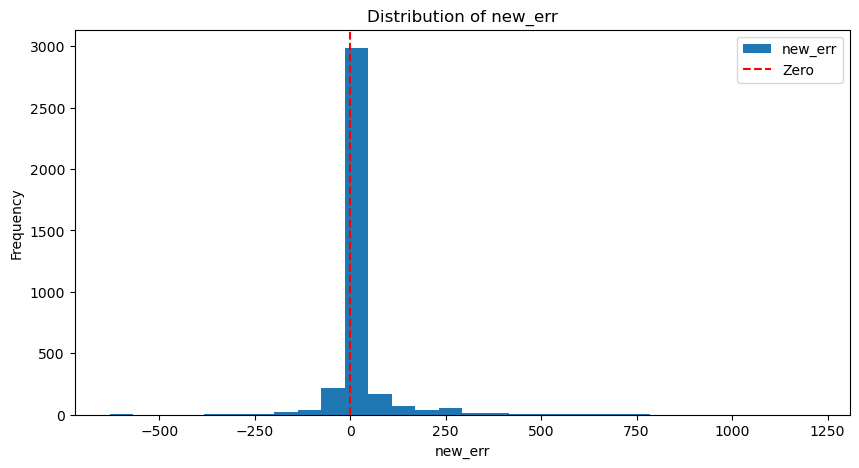

In [149]:
df.new_err.plot(kind='hist', bins=30, figsize=(10, 5), title='Distribution of new_err')
plt.xlabel('new_err')
plt.ylabel('Frequency')
#plt.xlim(-200, 200)
plt.axvline(0, color='red', linestyle='--', label='Zero')
plt.legend()
plt.show()

majority (roughly two thirds of the cases) have no error, but the positive errors seem more extreme, than the negative errors.

In [33]:
df.error_target.value_counts()

error_target
0    2301
1    1357
Name: count, dtype: int64

2301 cases are not flagged as errors.. and these are more than half of the cases.. imbalanced data as expected.. consider class weighting in modeling traning later.

<Axes: xlabel='error_target'>

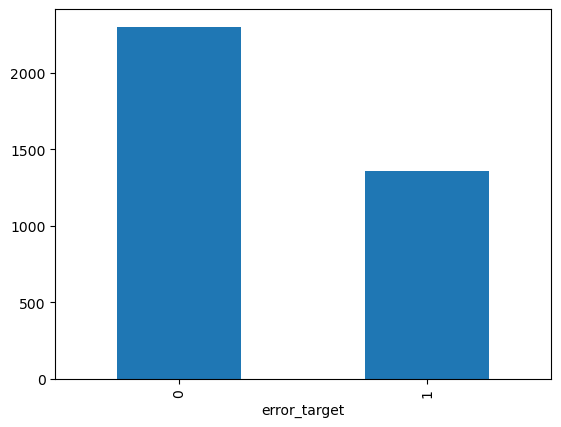

In [34]:
df.error_target.value_counts().plot(kind='bar')

In [39]:
df.tt_income.describe()

count    3588.000000
mean     1048.430641
std       938.993958
min         0.000000
25%        14.555000
50%       943.000000
75%      1501.750000
max      6428.889600
Name: tt_income, dtype: float64

<Axes: ylabel='Frequency'>

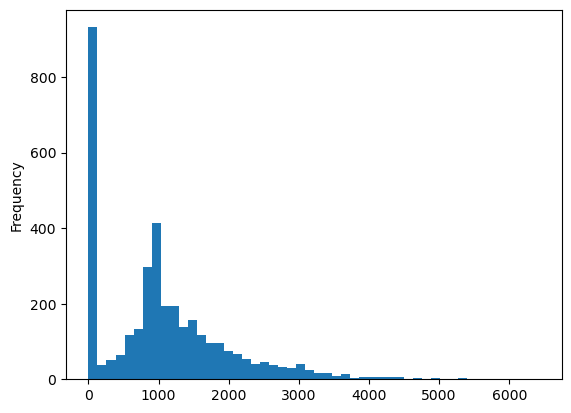

In [98]:
df['tt_income'].dropna().plot(kind='hist', bins=50)

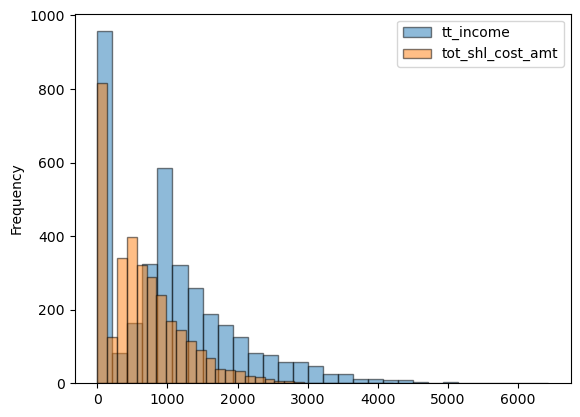

In [103]:
fig, ax = plt.subplots()
df['tt_income'].dropna().plot(kind='hist', bins=30, edgecolor='black', alpha=0.5, label='tt_income', ax=ax)
df['tot_shl_cost_amt'].dropna().plot(kind='hist', bins=30, edgecolor='black', alpha=0.5, label='tot_shl_cost_amt', ax=ax)
ax.legend()

median total income is $943.. median total shelter cost is $552.. and the median max snap benefit is $298. income vs cost scatter plot?

<Axes: xlabel='tt_income', ylabel='tot_shl_cost_amt'>

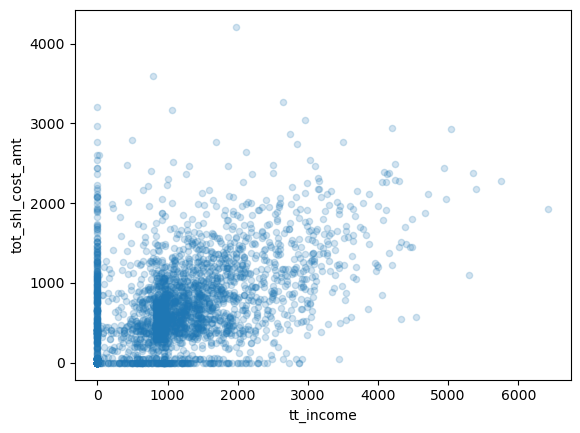

In [107]:
df.plot.scatter(x='tt_income', y='tot_shl_cost_amt', alpha=0.2)

no clear linear association between tt_income and tot_shl_cost_amt. seems highly clustered near zero; people with almost no income have rent/mortgage costs. look at their rent 'burden' by error amount variable?

<Axes: xlabel='tt_income', ylabel='tot_shl_cost_amt'>

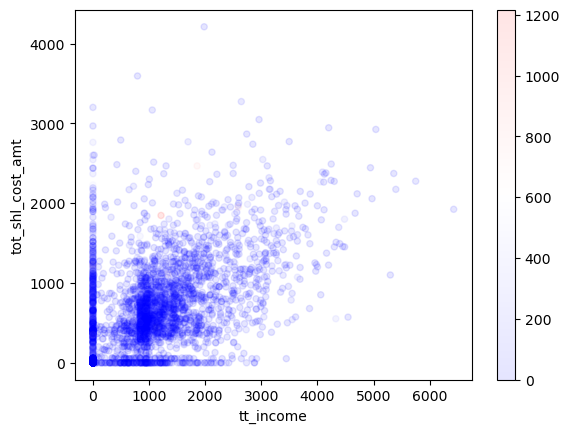

In [115]:
df.plot.scatter(x='tt_income', y='tot_shl_cost_amt', alpha=0.1, c=df['Error'], cmap='bwr')

In [36]:
df.tot_shl_cost_amt.describe()

count    3296.000000
mean      644.921696
std       569.885050
min         0.000000
25%       160.750000
50%       552.000000
75%       951.054993
max      4210.000000
Name: tot_shl_cost_amt, dtype: float64

In [40]:
df.max_snap.describe()

count    3655.000000
mean      544.355951
std       323.983261
min       298.000000
25%       298.000000
50%       298.000000
75%       785.000000
max      1789.000000
Name: max_snap, dtype: float64

In [54]:
df.groupby('grouprace')['error_target'].value_counts()

grouprace  error_target
1          0                933
           1                602
2          0                121
           1                102
3          0                103
           1                 60
4          0               1144
           1                593
Name: count, dtype: int64

error_target=1 means the case had an error. it seems grouprace 1 and 4 have higher number of cases so naturally they have higher number of errors. the imbalance is quite severe. need to come up with a strategy to handle this.. inverse probability weighting or?

<Axes: xlabel='grouprace'>

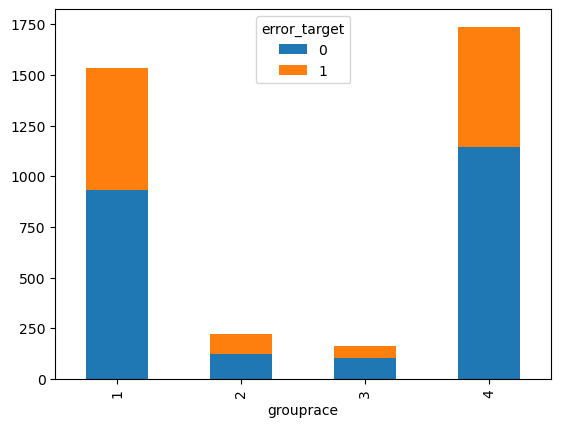

In [60]:
df.groupby('grouprace')['error_target'].value_counts().unstack().plot(kind='bar', stacked=True)

<Axes: xlabel='error_target'>

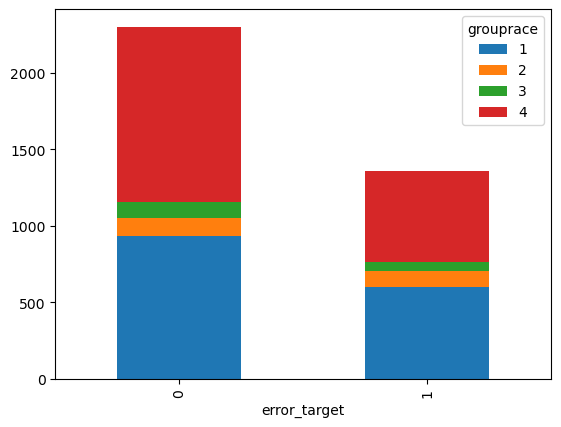

In [63]:
df.groupby('error_target')['grouprace'].value_counts().unstack().plot(kind='bar', stacked=True)

<Axes: xlabel='error_target'>

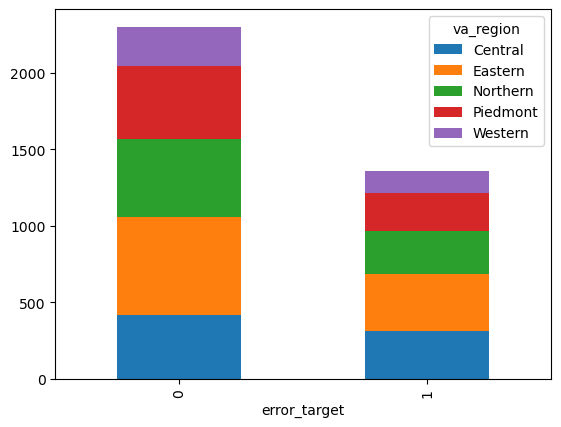

In [65]:
df.groupby('error_target')['va_region'].value_counts().unstack().plot(kind='bar', stacked=True)

Regionl distribution is not as severley imbalanced as I thought compared to the group_race distribution. 

<Axes: xlabel='main_error_type'>

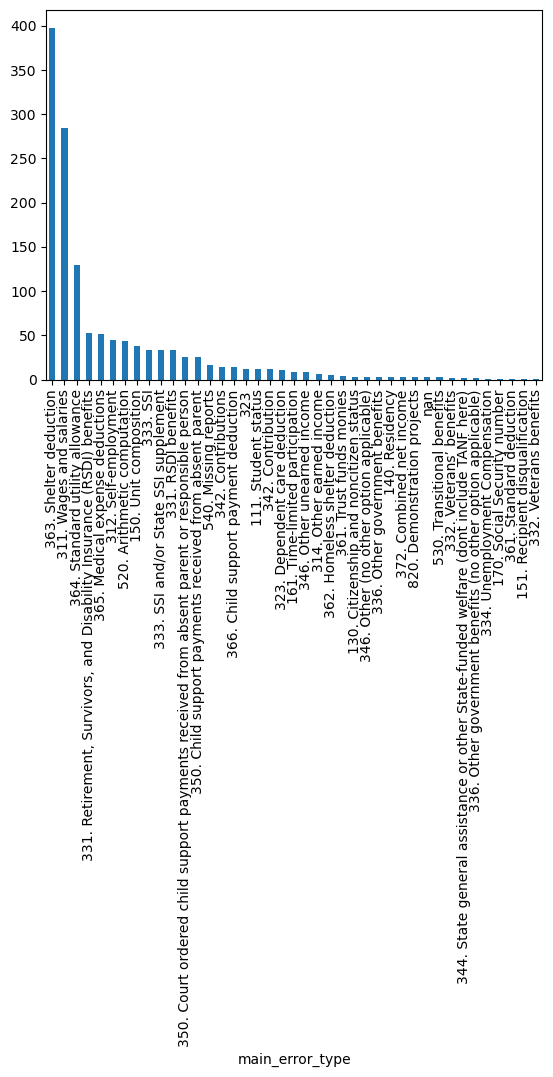

In [67]:
df[df['error_target'] == 1]['main_error_type'].value_counts(dropna=False).plot(kind='bar')

Out of the error_target=1 cases (n=1351), 363. shelter deduction is the most frequent main_error_type, followed by salary and utility. 

In [70]:
df['share_rent'].value_counts(dropna=False)

share_rent
0.000000      628
NaN           428
52.000000      25
414.000000     13
61.000000      11
             ... 
0.134628        1
0.015086        1
0.940835        1
0.334567        1
0.451282        1
Name: count, Length: 2458, dtype: int64

628 cases with share_rent=0; rent-to-income ratio; does it mean they don't pay rent? should both 0 and NAs be handled the same way? 

def of this column: Ratio of shelter cost to total income, calculated as: tot_shl_cost_amt / (case_uern_incm_amt + case_ern_incm_amt + 1). A value of 1 is added to the denominator to avoid division by zero.

<Axes: ylabel='Frequency'>

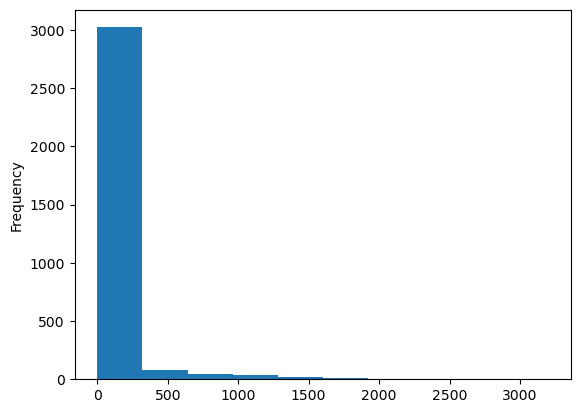

In [93]:
#share_rent distribution, excluding NAs.
df['share_rent'].dropna().plot(kind='hist', bins=10)

<Axes: ylabel='Frequency'>

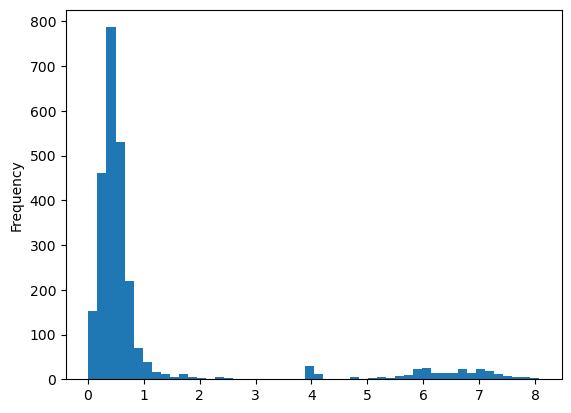

In [92]:
#excluding NAs and 0s, log transform share_rent values 

np.log1p(df[df['share_rent'] > 0]['share_rent'].dropna()).plot(kind='hist', bins=50)